<a href="https://colab.research.google.com/github/IngridAMorales/Predicting-Wine-Quality-Based-on-Its-Chemical-Properties/blob/random_forest/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
red_wine = pd.read_csv("winequality-red.csv", delimiter=";")
white_wine = pd.read_csv("winequality-white.csv", delimiter=";")

In [3]:
print(red_wine.shape)
print(white_wine.shape)

(1599, 12)
(4898, 12)


In [4]:
red_wine["wine_type"] = "0"
white_wine["wine_type"] = "1"

In [5]:
#combining wines
wine_data = pd.concat([red_wine, white_wine], axis=0)

# Check dataset information
print(wine_data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 710.6+ KB
None


In [6]:
print(wine_data.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality wine_type  
0      9.4        5         0  
1      9.8        5   

In [7]:
# Get summary statistics grouped by wine type
summary_stats = wine_data.groupby("wine_type").describe()
print(summary_stats)


          fixed acidity                                                \
                  count      mean       std  min  25%  50%  75%   max   
wine_type                                                               
0                1599.0  8.319637  1.741096  4.6  7.1  7.9  9.2  15.9   
1                4898.0  6.854788  0.843868  3.8  6.3  6.8  7.3  14.2   

          volatile acidity            ... alcohol       quality            \
                     count      mean  ...     75%   max   count      mean   
wine_type                             ...                                   
0                   1599.0  0.527821  ...    11.1  14.9  1599.0  5.636023   
1                   4898.0  0.278241  ...    11.4  14.2  4898.0  5.877909   

                                              
                std  min  25%  50%  75%  max  
wine_type                                     
0          0.807569  3.0  5.0  6.0  6.0  8.0  
1          0.885639  3.0  5.0  6.0  6.0  9.0  

[2 rows x 96

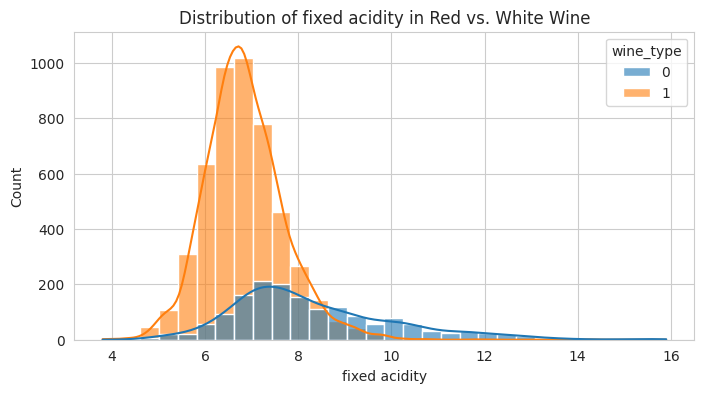

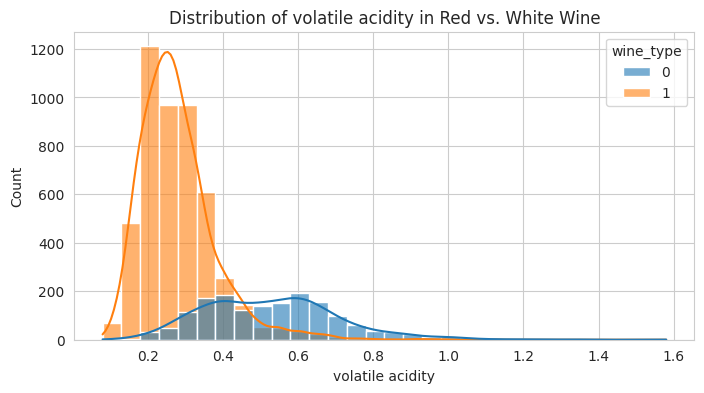

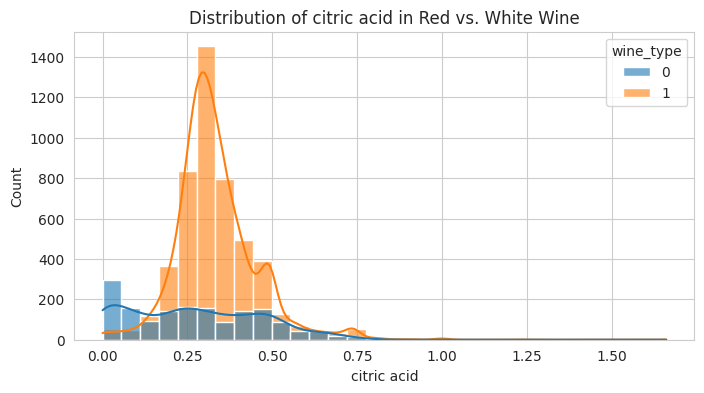

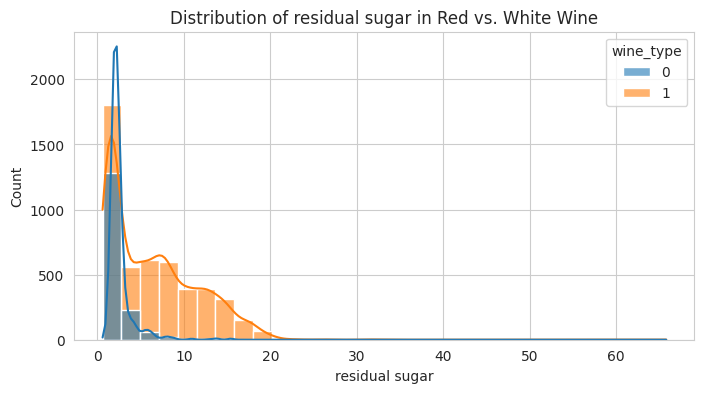

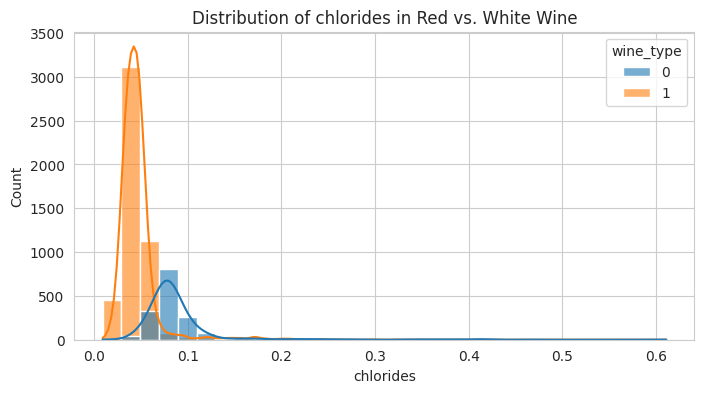

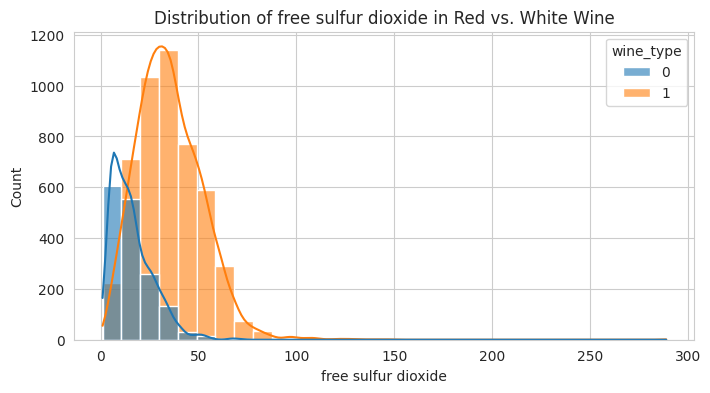

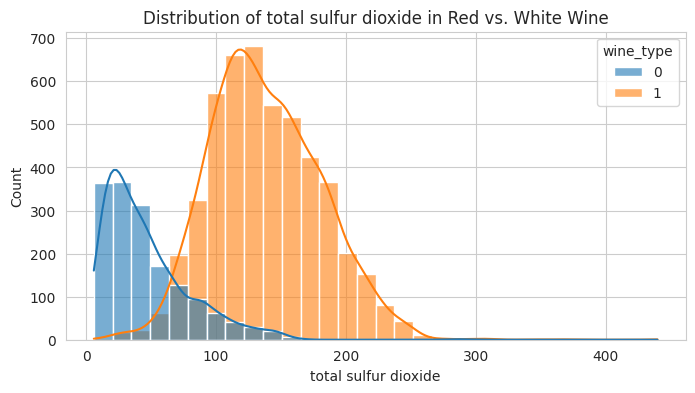

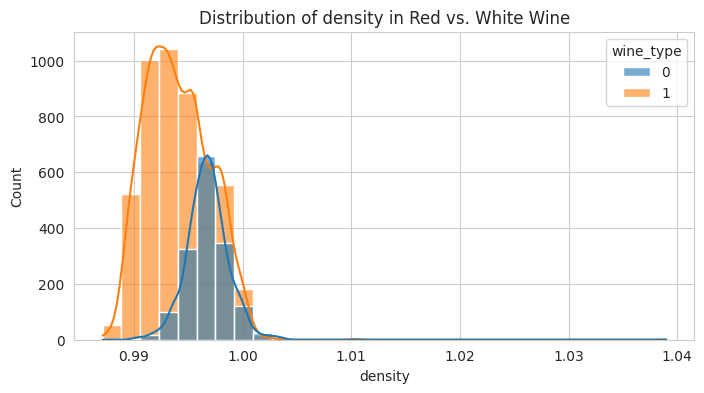

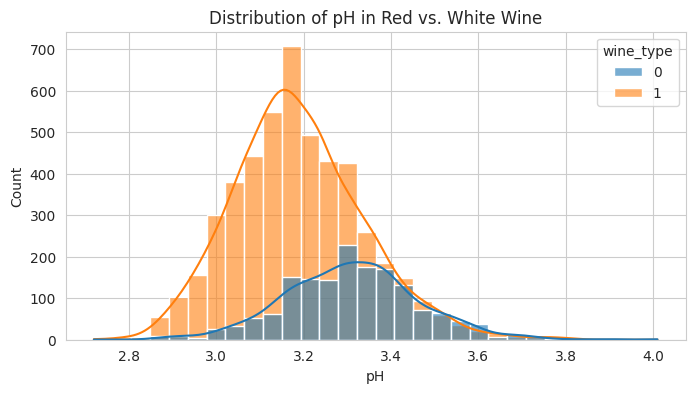

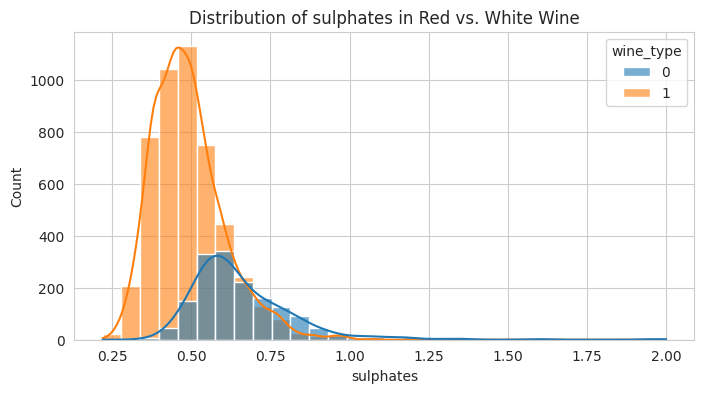

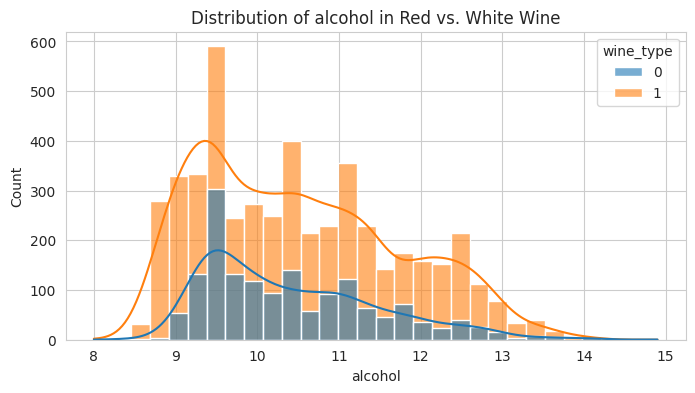

In [8]:
sns.set_style("whitegrid")

# Plot histograms for key features
features = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar","chlorides","free sulfur dioxide","total sulfur dioxide", "density","pH","sulphates", "alcohol"]

for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=wine_data, x=feature, hue="wine_type", kde=True, bins=30, alpha=0.6)
    plt.title(f"Distribution of {feature} in Red vs. White Wine")
    plt.show()


In [9]:
wine_data.groupby("wine_type")[features].describe().T

wine_type                      0            1
fixed acidity count  1599.000000  4898.000000
              mean      8.319637     6.854788
              std       1.741096     0.843868
              min       4.600000     3.800000
              25%       7.100000     6.300000
...                          ...          ...
alcohol       min       8.400000     8.000000
              25%       9.500000     9.500000
              50%      10.200000    10.400000
              75%      11.100000    11.400000
              max      14.900000    14.200000

[88 rows x 2 columns]

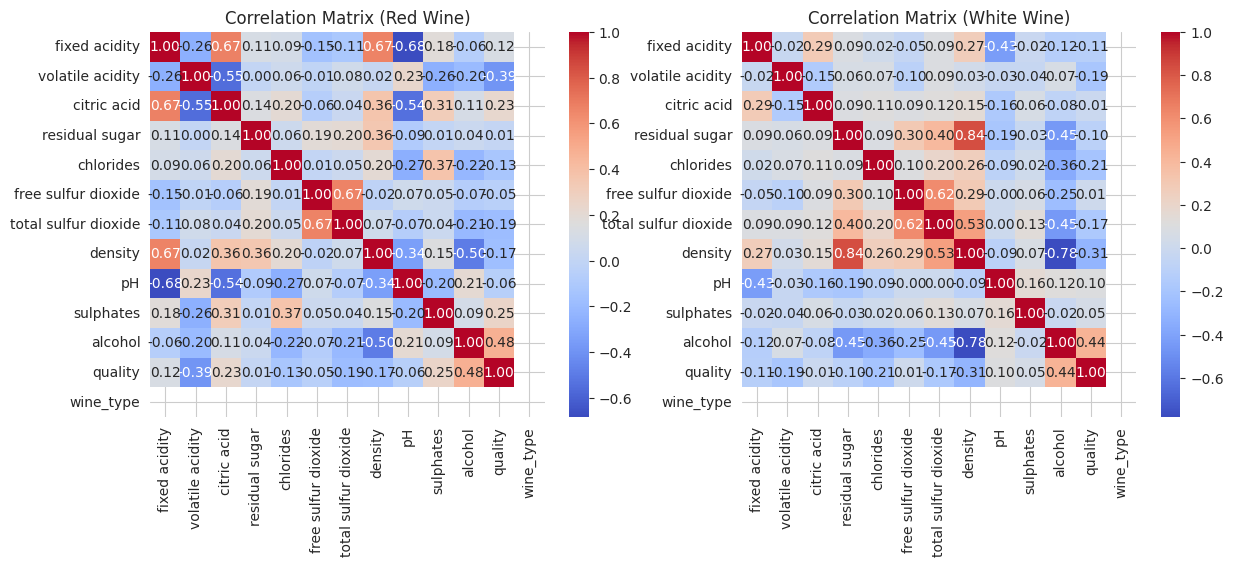

In [10]:
# Compute correlation matrices separately for red and white wines
corr_red = red_wine.corr()
corr_white = white_wine.corr()

# Plot heatmaps
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_red, annot=True, cmap="coolwarm", fmt=".2f", ax=ax[0])
ax[0].set_title("Correlation Matrix (Red Wine)")
sns.heatmap(corr_white, annot=True, cmap="coolwarm", fmt=".2f", ax=ax[1])
ax[1].set_title("Correlation Matrix (White Wine)")
plt.show()


Alcohol has the highest positive relationship with the quality in red wine. The weakest relationships are the residual sugar, free sulfur dioxide, and pH.

For white wine, sulphates, pH, free sulfur dioxide, and citric acid have weak relationships with quality.

Maybe we should keep two different models for white and red

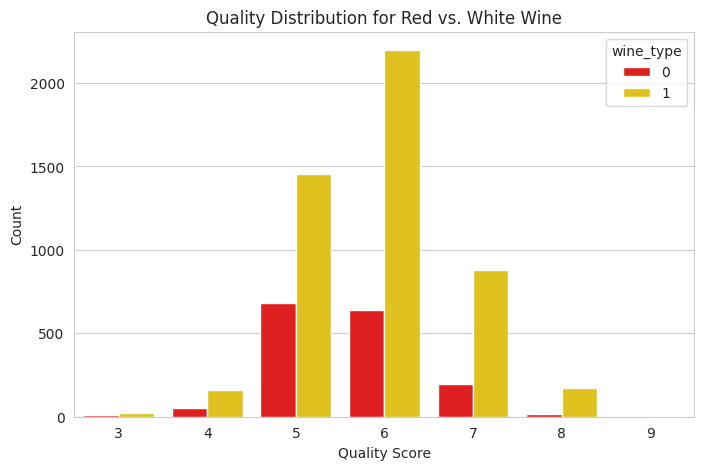

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=wine_data, x="quality", hue="wine_type", palette=["red", "gold"])
plt.title("Quality Distribution for Red vs. White Wine")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()


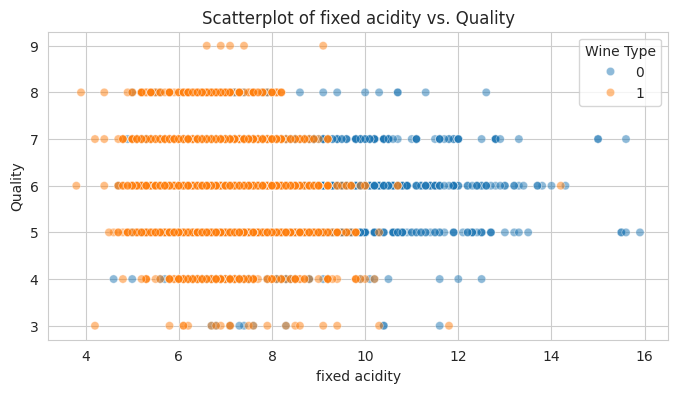

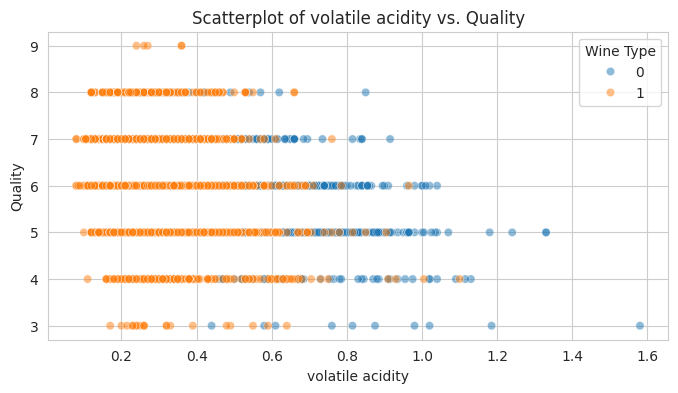

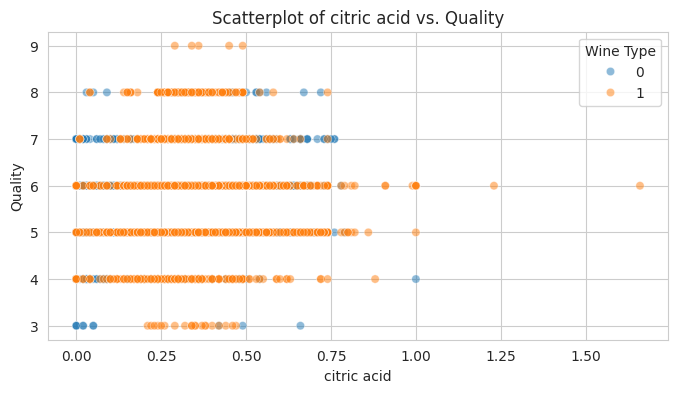

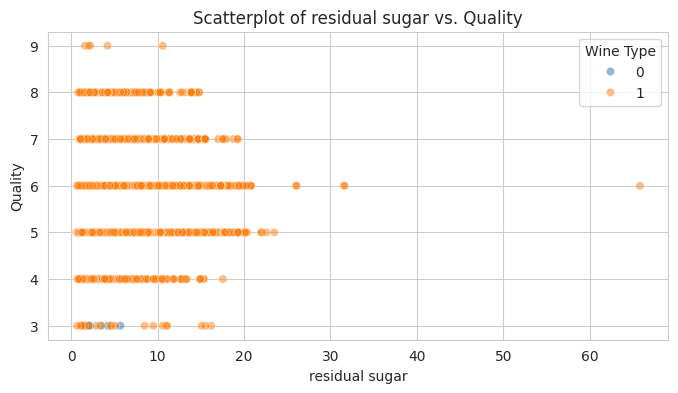

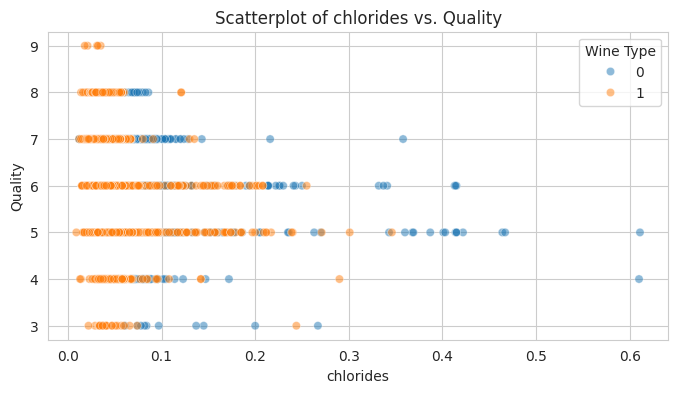

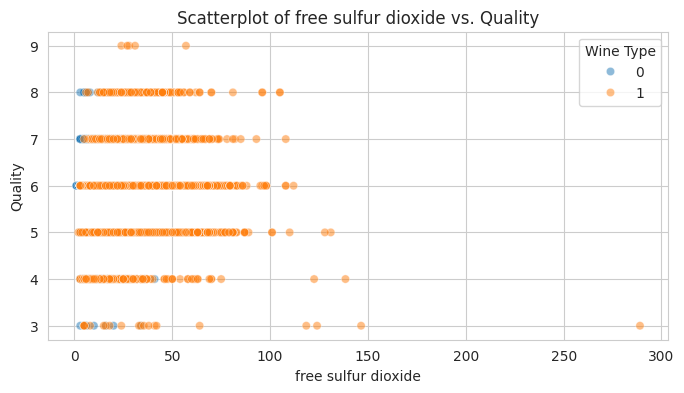

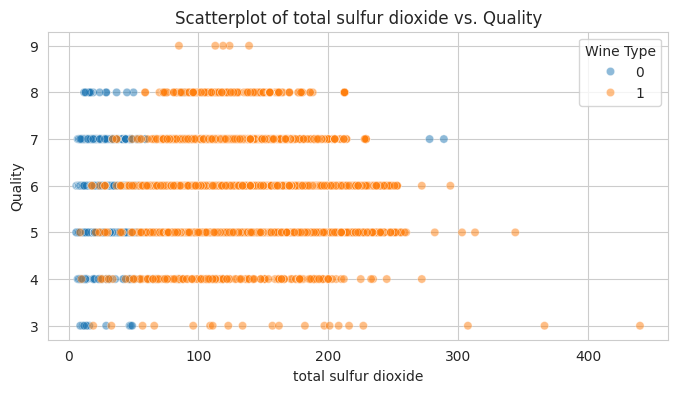

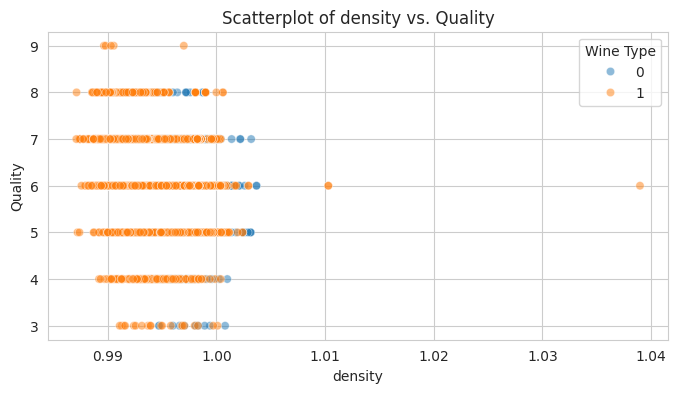

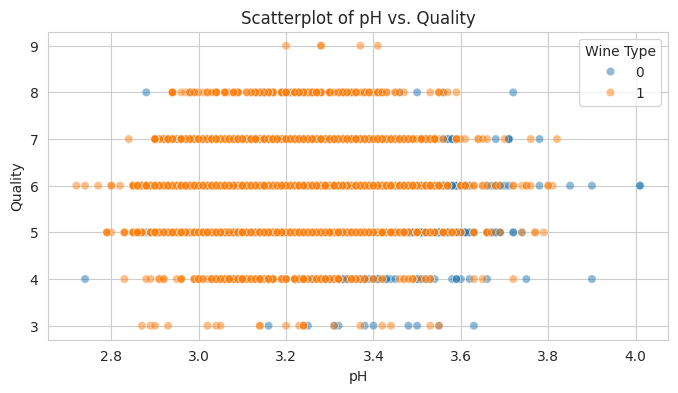

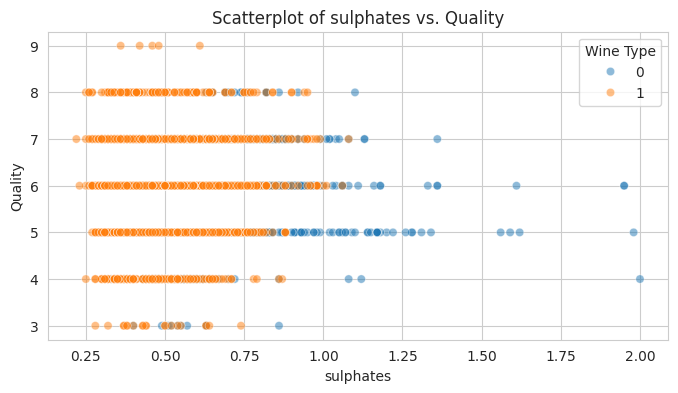

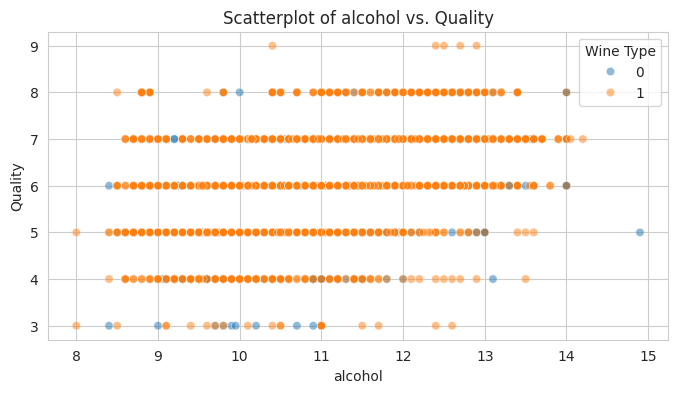

In [12]:

# List of features to test for linearity
features = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides",
    "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates", "alcohol"
]

# Plot scatterplots of each feature against quality
for feature in features:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(data=wine_data, x=feature, y="quality", hue="wine_type", alpha=0.5)
    plt.title(f"Scatterplot of {feature} vs. Quality")
    plt.xlabel(feature)
    plt.ylabel("Quality")
    plt.legend(title="Wine Type")
    plt.show()


In [52]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.model_selection import train_test_split

X = wine_data.drop(columns=["quality"])
y = wine_data["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_distributions_regressor = {
    'n_estimators': [450, 600, 800, 1000, 1300],
    'max_depth': [25, 50, 100, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['squared_error', 'absolute_error']
}

param_distributions_classifier = {
    'n_estimators': [450, 600, 800, 1000],
    'max_depth': [25, 50, 100, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

stratified_kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search_mse = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_distributions=param_distributions_regressor,
                           cv=stratified_kfold,
                           scoring='neg_mean_squared_error',
                           n_jobs=-1,
                           n_iter=100
)

grid_search_accuracy = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_distributions=param_distributions_classifier,
                           cv=stratified_kfold,
                           scoring='accuracy',
                           n_jobs=-1,
                           n_iter=100
)

grid_search_mse.fit(X_train, y_train)
grid_search_accuracy.fit(X_train, y_train)

best_rf_mse = grid_search_mse.best_estimator_
y_pred = best_rf_mse.predict(X_test)

best_rf_accuracy = grid_search_accuracy.best_estimator_
y_pred = best_rf_accuracy.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Best MSE: {mse:.4f}")
print(f"Best Accuracy: {accuracy:.4f}")

print("Best MSE Parameters:", grid_search_mse.best_params_)
print("Best Accuracy Parameters:", grid_search_accuracy.best_params_)

Best MSE: 0.4469
Best Accuracy: 0.6715
Best MSE Parameters: {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 50, 'criterion': 'squared_error'}
Best Accuracy Parameters: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 100, 'criterion': 'entropy'}


Best MSE: 0.4208
Best Accuracy: 0.6885

param_distributions_regressor = {
    'n_estimators': [450, 600, 800, 1000, 1300], # Reintroducing some mid range.
    'max_depth': [25, 50, 90, None], # Reintroducing some mid range.
    'min_samples_split': [2, 5, 10, 20], # Reintroducing higher end.
    'min_samples_leaf': [1, 2, 4], # Reintroducing higher end.
    'max_features': ['sqrt', 'log2'],
    'criterion': ['squared_error', 'absolute_error']
}

param_distributions_classifier = {
    'n_estimators': [450, 600, 800, 1000], # Reintroducing some mid range.
    'max_depth': [25, 50, 90, None], # Reintroducing some mid range.
    'min_samples_split': [2, 5, 10, 20], # Reintroducing higher end.
    'min_samples_leaf': [1, 2, 4], # Reintroducing higher end.
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

Best MSE: 0.4238
Best Accuracy: 0.6838

param_distributions_regressor = {
    'n_estimators': [100, 200, 450, 600, 800, 1000, 1300],
    'max_depth': [10, 25, 50, 90, 120, None],
    'min_samples_split': [2, 5, 10, 20, 40],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['squared_error', 'absolute_error']  # Correct criterion for regressor
}

param_distributions_classifier = {
    'n_estimators': [200, 450, 600, 800, 1000],
    'max_depth': [10, 25, 50, 90, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

Best MSE: 0.4508
Best Accuracy: 0.6731

param_distributions_regressor = {
    'n_estimators': [100, 200, 450, 600, 800],
    'max_depth': [10, 25, 50, 90, 120, None],
    'min_samples_split': [2, 5, 10, 20, 40],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']
}

param_distributions_classifier = {
    'n_estimators': [50, 100, 200, 450, 600, 800],
    'max_depth': [10, 25, 50, 90, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy']
}

Best MSE: 0.4469
Best Accuracy: 0.6808

param_distributions_regressor = {
    'n_estimators': [600, 800, 1000, 1300], #focusing on the higher end.
    'max_depth': [50, 90, 120, None], #focusing on the higher end.
    'min_samples_split': [2, 5, 10], #removing the higher end.
    'min_samples_leaf': [1, 2], #removing the higher end.
    'max_features': ['sqrt', 'log2'],
    'criterion': ['squared_error', 'absolute_error']
}

param_distributions_classifier = {
    'n_estimators': [600, 800, 1000], #focusing on the higher end.
    'max_depth': [50, 90, None], #focusing on the higher end.
    'min_samples_split': [2, 5, 10], #removing the higher end.
    'min_samples_leaf': [1, 2], #removing the higher end.
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

# Feature Selection

In [15]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.model_selection import train_test_split

features = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides",
    "total sulfur dioxide", "density", "sulphates", "alcohol", "wine_type"
]

X = wine_data.drop(columns=["quality"])
y = wine_data["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 2: Split the temporary set into validation (50%) and test (50%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
X_val = X_val.to_numpy()
y_val = y_val.to_numpy()
y_train  = y_train.to_numpy()
y_test = y_test.to_numpy()
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"Y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {y_test.shape}")

X_train shape: (4547, 12)
Y_train shape: (4547,)
X_val shape: (975, 12)
Y_val shape: (975,)
X_test shape: (975, 12)
Y_test shape: (975,)


# Random Forest

In [46]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import train_test_split

def train_and_evaluate_rf(X, y, n_estimators=800, n_iterations=100, interval=10, random_state=42, max_depth=100, min_samples_split=2, min_samples_leaf=1, max_features='log2'):
    """
    Trains and evaluates a Random Forest model iteratively, printing training
    and validation metrics at specified intervals.
    """

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=random_state)

    print(f"Starting training with {n_iterations} iterations...")

    if y.dtype in ['int64', 'int32', 'int16', 'int8', 'uint64', 'uint32', 'uint16', 'uint8']:
        is_classification = True
        model = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state, warm_start=True, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, max_features = max_features)
    else:
        is_classification = False
        model = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state, warm_start=True, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, max_features = max_features)

    for i in range(0, n_iterations, interval):
        if i == 0:
            model.n_estimators = interval
        else:
            model.n_estimators = i + interval
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        train_mse = mean_squared_error(y_train, y_train_pred)
        val_mse = mean_squared_error(y_val, y_val_pred)

        if is_classification:
            train_accuracy = accuracy_score(y_train, y_train_pred)
            val_accuracy = accuracy_score(y_val, y_val_pred)
            print(f"Iteration {i}: Train MSE = {train_mse:.4f}, Val MSE = {val_mse:.4f}, Train Accuracy = {train_accuracy:.4f}, Val Accuracy = {val_accuracy:.4f}")
        else:
            train_accuracy = accuracy_score(y_train, np.round(y_train_pred))
            val_accuracy = accuracy_score(y_val, np.round(y_val_pred))
            print(f"Iteration {i}: Train MSE = {train_mse:.4f}, Val MSE = {val_mse:.4f}, Train Accuracy = {train_accuracy:.4f}, Val Accuracy = {val_accuracy:.4f}")

X = wine_data.drop(columns=["quality"])
y = wine_data["quality"]

train_and_evaluate_rf(X, y, n_estimators=500, n_iterations=100, interval=10, max_depth=4, min_samples_split=2, min_samples_leaf=2, max_features='log2')

Starting training with 100 iterations...
Iteration 0: Train MSE = 0.6365, Val MSE = 0.6615, Train Accuracy = 0.5586, Val Accuracy = 0.5377
Iteration 10: Train MSE = 0.6173, Val MSE = 0.6400, Train Accuracy = 0.5592, Val Accuracy = 0.5454
Iteration 20: Train MSE = 0.6198, Val MSE = 0.6423, Train Accuracy = 0.5611, Val Accuracy = 0.5431
Iteration 30: Train MSE = 0.6273, Val MSE = 0.6462, Train Accuracy = 0.5567, Val Accuracy = 0.5462
Iteration 40: Train MSE = 0.6192, Val MSE = 0.6423, Train Accuracy = 0.5599, Val Accuracy = 0.5477
Iteration 50: Train MSE = 0.6234, Val MSE = 0.6508, Train Accuracy = 0.5580, Val Accuracy = 0.5392
Iteration 60: Train MSE = 0.6209, Val MSE = 0.6423, Train Accuracy = 0.5586, Val Accuracy = 0.5454
Iteration 70: Train MSE = 0.6261, Val MSE = 0.6454, Train Accuracy = 0.5569, Val Accuracy = 0.5423
Iteration 80: Train MSE = 0.6234, Val MSE = 0.6446, Train Accuracy = 0.5582, Val Accuracy = 0.5431
Iteration 90: Train MSE = 0.6261, Val MSE = 0.6446, Train Accuracy = 